In [8]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

# Part 1 (a)
A1 = np.array([[1, 0], [0, 1], [1, 1]])
b1 = np.array([1, 2, 2])

x, _, _, _ = np.linalg.lstsq(A1, b1)
print(x)

[0.6667 1.6667]


In [15]:
# Part 1 (b)
t = np.array([0, 1, 2, 3, 4])
y = np.array([1.1, 2.0, 4.9, 10.2, 16.8])

A = np.vstack([np.ones_like(t), t, t**2]).T
b = y

print(A)
print(b)

[[ 1  0  0]
 [ 1  1  1]
 [ 1  2  4]
 [ 1  3  9]
 [ 1  4 16]]
[ 1.1  2.   4.9 10.2 16.8]


Coefficients [1.0514 0.0171 0.9857]


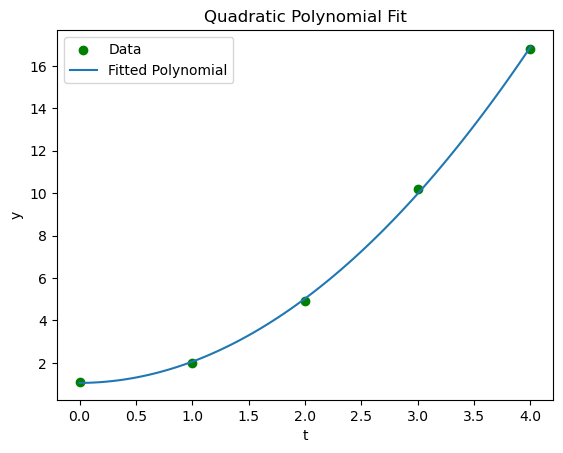

In [23]:
# Part 1 (c)
x, _, _, _ = np.linalg.lstsq(A, b)
print("Coefficients", x)

t_plot = np.linspace(0, 4, 100)
y_plot = x[0] + x[1]*t_plot + x[2]*t_plot**2

plt.scatter(t, y, color = 'green', label="Data")
plt.plot(t_plot, y_plot, label="Fitted Polynomial")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Quadratic Polynomial Fit")
plt.legend()
plt.show()

In [25]:
# Part 2 (a)
def gram_schmidt(A):
    m, n = A.shape
    Q = np.zeros((m, n))

    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            v = v - np.dot(Q[:, i], A[:, j]) * Q[:, i]

        Q[:, j] = v / np.linalg.norm(v)

    return Q

In [26]:
# Part 2 (b)
A2 = np.array([[1, 0, 1], [-1, 1, 0], [0, -1, -1]], dtype=float)

Q = gram_schmidt(A2)

print("Q:")
print(Q)
print("Q^T Q:")
print(Q.T@Q)

Q:
[[ 0.7071  0.4082  0.2673]
 [-0.7071  0.4082 -0.8018]
 [ 0.     -0.8165  0.5345]]
Q^T Q:
[[ 1.     -0.      0.7559]
 [-0.      1.     -0.6547]
 [ 0.7559 -0.6547  1.    ]]


In [30]:
# Part 2 (c)
b2 = np.array([1, 2, 3], dtype=float)

R = Q.T @ A2
c = Q.T @ b2

print("R:")
print(R)
print("c:")
print(c)
x_qr = np.linalg.solve(R, c)
print("QR Soln:", x_qr)
x_lstsq = np.linalg.lstsq(A2, b2)[0]
print("lstsq soln", x_lstsq)

R:
[[ 1.4142 -0.7071  0.7071]
 [-0.      1.2247  1.2247]
 [ 1.069  -1.3363 -0.2673]]
c:
[-0.7071 -1.2247  0.2673]
QR Soln: [-0.1133 -0.1133 -0.8867]
lstsq soln [-0.3333 -0.3333 -0.6667]
